<a href="https://colab.research.google.com/github/etcex2969-spec/-AIFFEL_quest_eng/blob/main/v4_5_live_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

v4.5_Final_Live

In [ ]:
!pip install -U langgraph langchain langchain-community langchain-openai faiss-cpu python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 88.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 74.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 9.2 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [ ]:
import os
from dotenv import load_dotenv

# .env 파일에서 환경 변수를 로드합니다.
# (예: OPENAI_API_KEY='your_api_key_here')
# 이 파일을 Google Drive의 현재 작업 디렉토리(`/content/drive/MyDrive/your_project_folder`)에 생성해야 합니다.
load_dotenv()

# OpenAI API 키 설정
# Colab Secrets나 환경 변수에서 가져오거나, .env 파일에서 로드합니다.
if not os.getenv("OPENAI_API_KEY"):
    # API 키가 설정되지 않았다면, 여기에 직접 입력하거나 사용자에게 입력하도록 요청할 수 있습니다.
    # 예시: os.environ["OPENAI_API_KEY"] = "your_openai_api_key_here"
    print("경고: OPENAI_API_KEY 환경 변수가 설정되지 않았습니다. .env 파일을 확인하거나 직접 설정해주세요.")
else:
    print("OPENAI_API_KEY가 성공적으로 로드되었습니다.")

# LangChain 및 LangGraph 환경 설정은 다음 셀에서 계속됩니다.

In [ ]:
# 구글 코랩 환경에서 개인 구글 드라이브를 하드디스크처럼 연결하기 위해 drive 모듈을 가져옵니다냥!
from google.colab import drive
# 파일 시스템 경로 변경 및 디렉토리 관리를 위해 파이썬 표준 os 라이브러리를 가져옵니다냥!
import os

# 프로젝트 환경 설정을 자동화하기 위한 setup_environment 함수를 정의합니다냥!
def setup_environment():
    # '/content/drive' 경로에 유저의 구글 드라이브를 실시간으로 마운트(연결)합니다냥!
    drive.mount('/content/drive')

    # 작업하려는 폴더 경로를 지정합니다냥!
    project_path = '/content/drive/MyDrive/your_project_folder'

    # [수정] 폴더가 존재하는지 확인하고, 없으면 새로 만듭니다냥!
    if not os.path.exists(project_path):
        os.makedirs(project_path)
        print(f"새로운 폴더를 생성했습니다냥: {project_path}")

    # 작업 디렉토리를 해당 경로로 이동시킵니다냥!
    os.chdir(project_path)
    # 디렉토리 이동이 성공하면 터미널에 완료 메시지를 시원하게 출력합니다냥!
    print(f"Google Drive 마운트 및 작업 디렉토리 설정 완료: {os.getcwd()}")

# 위에서 정의한 환경 설정 함수를 실제로 호출하여 실행합니다냥!
setup_environment()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
새로운 폴더를 생성했습니다냥: /content/drive/MyDrive/your_project_folder
Google Drive 마운트 및 작업 디렉토리 설정 완료: /content/drive/MyDrive/your_project_folder


In [ ]:
# 구글 드라이브 모듈이 정상 작동하는지 한 번 더 체크하기 위해 가져옵니다냥!
from google.colab import drive

# 구글 드라이브를 '/content/drive' 경로에 다시 한번 안전하게 마운트해 줍니다냥!
drive.mount('/content/drive')

# 마운트된 드라이브 폴더 내에 저장할 가상의 텍스트 파일 경로를 문자열로 지정합니다냥!
file_path = '/content/drive/MyDrive/sample_data.txt'

# 지정한 경로에 파일 쓰기 모드('w')로 서랍을 열고, 안전한 닫기를 위해 with 문을 씁니다냥!
with open(file_path, 'w') as f:
    # 텍스트 파일 안에 샘플 문자열을 뽱!!! 하고 입력해 둡니다냥!
    f.write("This is a sample text file.")

# 위에서 방금 저장한 텍스트 파일을 이번에는 읽기 모드('r')로 다시 열어젖힙니다냥!
with open(file_path, 'r') as f:
    # 파일 내부의 텍스트 덩어리를 끝까지 읽어와서 content 변수에 담아냅니다냥!
    content = f.read()
# 읽어온 텍스트 내용이 저장 장치에 잘 들어갔는지 콘솔 창에 촥 출력해 봅니다냥!
print(content)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
This is a sample text file.


In [ ]:
# 결제 억까 없는 무료 야후 파이낸스 라이브러리를 코랩 환경에 조용히(-q) 설치합니다냥!
!pip install -q yfinance
# 설치한 야후 파이낸스 모듈을 주식 데이터 호출 치트키인 'yf'라는 별명으로 가져옵니다냥!
import yfinance as yf

# yf.download 함수를 써서 엔비디아(NVDA)의 2025년 1월부터 현재 2026년 6월까지의 주가 데이터를 다운로드합니다냥!
df = yf.download("NVDA", start="2025-01-01", end="2026-06-01")
# 다운로드한 판다스 데이터프레임(df)을 로컬 경로에 'nvda_financial_data.csv' 파일로 구워버립니다냥!
df.to_csv("nvda_financial_data.csv") # 얄공조 공식 금융 데이터셋 빌드 완료구구만유!

/tmp/ipykernel_3992/3461009813.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("NVDA", start="2025-01-01", end="2026-06-01")
[*********************100%***********************]  1 of 1 completed


v4.5_Final_Live

In [ ]:
import logging
import os
from dataclasses import dataclass

# [에러 방지 1] 랭체인 최신 라이브러리 (v0.3+) 및 OpenAI 인프라 로드
from dotenv import load_dotenv

try:
    # 최신 랭체인에서 RetrievalQA는 보통 이 경로를 통해 권장됩니다냥!
    from langchain.chains import create_retrieval_chain
    from langchain.chains.combine_documents import create_stuff_documents_chain
    # 레거시 지원을 위한 시도
    from langchain.chains import RetrievalQA
except ImportError:
    try:
        from langchain_community.chains import RetrievalQA
    except ImportError:
        # 최후의 수단: 에러가 나더라도 코드 실행이 멈추지 않게 방어 로직을 짭니다냥!
        RetrievalQA = None

from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAI, OpenAIEmbeddings
from langgraph.graph import StateGraph, END
import openai

# 로깅 설정 (출력 가시성 최적화)
logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')
logger = logging.getLogger(__name__)

# ==========================================
# 🔐 1. OpenAI API 환경 설정 및 가상 DB 구축 서랍
# ==========================================
# .env 파일에서 환경 변수를 로드합니다. (이전 셀에서 이미 처리되었을 수 있음)
# load_dotenv()

# OpenAI API 키 설정 (환경 변수에서 가져옵니다)
openai.api_key = os.getenv("OPENAI_API_KEY")

# API 키가 제대로 설정되었는지 확인하는 로직 추가
if not openai.api_key:
    logger.error("OPENAI_API_KEY가 설정되지 않았거나 유효하지 않습니다. .env 파일을 확인해주세요.")
    # API 키가 없으면 나머지 작업을 진행할 수 없으므로, 여기서 강제로 종료하거나 대체 로직을 구현할 수 있습니다.
    # 예를 들어, return을 통해 함수 실행을 중단하거나, 기본값을 설정할 수 있습니다.

def build_temporary_vectorstore():
    sample_texts = [
        "지정학적 리스크나 전쟁 발발 시 외환 시장은 원달러 환율이 급등하는 경향이 있다.",
        "과거 1970년대 오일쇼크 당시 자산 시장은 단기 공포로 오버슈팅했으나, 펀더멘탈은 회복되었다.",
        "초거대 자금(큰손)은 호가창 불균형을 이용해 개미 참여자들의 패닉 셀을 유도하므로 추종 매매에 유의해야 한다.",
        "투자 조언이나 100% 수익 보장이라는 단어는 컴플라이언스 가드레일에 의해 엄격히 금지된다."
    ]
    embeddings = OpenAIEmbeddings()
    db = FAISS.from_texts(sample_texts, embeddings)
    return db

try:
    if openai.api_key: # API 키가 있을 때만 벡터 DB 생성 시도
        vectorstore = build_temporary_vectorstore()
        logger.info("🎯 실전용 인메모리 FAISS 지식 베이스 구축 완료냥!")
    else:
        vectorstore = None
        logger.warning("OPENAI_API_KEY가 없어 벡터 DB를 구축할 수 없습니다.")
except Exception as e:
    logger.error(f"벡터 DB 생성 실패: {e}")
    vectorstore = None

llm = OpenAI(model="gpt-4o-mini", temperature=0.2)
if vectorstore and RetrievalQA:
    retrieval_qa = RetrievalQA.from_chain_type(llm=llm, retriever=vectorstore.as_retriever(), chain_type="stuff")
else:
    retrieval_qa = None

# ... (이하 에이전트 로직 동일) ...

@dataclass
class AgentState:
    mcp_context: str = ""
    market_sentiment: str = ""
    analyst_opinion: str = ""
    step_back_opinion: str = ""
    react_answer: str = ""
    risk_assessment: str = ""
    final_report: str = ""
    user_feedback: str = ""
    feedback_category: str = ""
    model_version: str = "v4.5_Final_Live"
    error_message: str = ""

def llm_call(prompt: str) -> str:
    try:
        from openai import OpenAI as OpenAIClient
        client = OpenAIClient(api_key=os.getenv("OPENAI_API_KEY")) # 명시적으로 API 키 전달
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": "당신은 최고 수준의 금융 인공지능 전략가입니다."},
                {"role": "user", "content": prompt}
            ],
            temperature=0.2
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"[추론 결과]: 위기 대응 전략 도출 완료. (API 연결 확인 필요) 에러: {e}"

def research_agent(state: AgentState) -> AgentState:
    state.mcp_context = "지정학적 충돌 발생 상황 데이터 수집 완료"
    state.market_sentiment = "공포 지수 급상승 중"
    return state

def analyst_agent(state: AgentState) -> AgentState:
    if retrieval_qa:
        state.analyst_opinion = retrieval_qa.invoke(state.mcp_context)["result"]
    else:
        state.analyst_opinion = "역사적으로 전쟁 시 달러 가치는 상승하는 경향을 보입니다."
    return state

def step_back_agent(state: AgentState) -> AgentState:
    state.step_back_opinion = llm_call(f"거시적 관점 분석: {state.analyst_opinion}")
    return state

def react_loop_agent(state: AgentState) -> AgentState:
    state.react_answer = "자산 방어를 위해 달러 비중 확대를 권고합니다."
    return state

def risk_agent(state: AgentState) -> AgentState:
    state.risk_assessment = "리스크 수준: 높음. 분산 투자 필요."
    return state

def report_agent(state: AgentState) -> AgentState:
    state.final_report = f"[최종 리포트]\n대응: {state.react_answer}\n평가: {state.risk_assessment}"
    return state

def feedback_agent(state: AgentState) -> AgentState:
    state.feedback_category = "Positive"
    return state

builder = StateGraph(AgentState)
builder.add_node("Research_Agent", research_agent)
builder.add_node("Analyst_Agent", analyst_agent)
builder.add_node("StepBack_Agent", step_back_agent)
builder.add_node("ReAct_Agent", react_loop_agent)
builder.add_node("Risk_Agent", risk_agent)
builder.add_node("Report_Agent", report_agent)
builder.add_node("Feedback_Agent", feedback_agent)

builder.set_entry_point("Research_Agent")
builder.add_edge("Research_Agent", "Analyst_Agent")
builder.add_edge("Analyst_Agent", "StepBack_Agent")
builder.add_edge("StepBack_Agent", "ReAct_Agent")
builder.add_edge("ReAct_Agent", "Risk_Agent")
builder.add_edge("Risk_Agent", "Report_Agent")
builder.add_edge("Report_Agent", "Feedback_Agent")
builder.add_edge("Feedback_Agent", END)

workflow = builder.compile()

if __name__ == "__main__":
    initial_state = AgentState()
    initial_state.user_feedback = "훌륭합니다!"
    final_output_state = workflow.invoke(initial_state)
    print(final_output_state["final_report"])


/tmp/ipykernel_3992/2392579171.py:16: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.chains import RetrievalQA
ERROR:__main__:벡터 DB 생성 실패: Error code: 401 - {'error': {'message': 'Incorrect API key provided: your-ope************here. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_api_key'}}


[최종 리포트]
대응: 자산 방어를 위해 달러 비중 확대를 권고합니다.
평가: 리스크 수준: 높음. 분산 투자 필요.


### LangGraph 워크플로우 예시

아래 코드는 `wq1e9vVOOtyR` 셀에서 정의된 `AgentState`와 다양한 에이전트 함수(`research_agent`, `analyst_agent` 등)를 사용하여 LangGraph 워크플로우를 구축하고 실행하는 방법을 보여줍니다.

이 예시는 에이전트들이 순차적으로 작업을 처리하며 최종 보고서를 생성하는 간단한 파이프라인을 구성합니다.

In [3]:
from typing import TypedDict
from langgraph.graph import StateGraph, END
from dataclasses import dataclass

# 1. 상태(State) 정의
@dataclass
class AgentState:
    mcp_context: str = ""
    analyst_opinion: str = ""
    final_report: str = ""
    user_feedback: str = ""

# 2. 에이전트 노드 함수 정의
def research_agent(state: AgentState) -> AgentState:
    print("[Research] 데이터 수집 중...")
    state.mcp_context = "최신 시장 동향 데이터 수집 완료"
    return state

def analyst_agent(state: AgentState) -> AgentState:
    print("[Analyst] 데이터 분석 중...")
    state.analyst_opinion = f"'{state.mcp_context}'를 기반으로 분석한 결과, 긍정적 신호가 포착되었습니다."
    return state

def report_agent(state: AgentState) -> AgentState:
    print("[Reporter] 최종 보고서 작성 중...")
    state.final_report = f"### 최종 보고서 ###\n분석 결과: {state.analyst_opinion}\n피드백: {state.user_feedback}"
    return state

# 3. LangGraph 워크플로우 구축
builder = StateGraph(AgentState)

builder.add_node("research", research_agent)
builder.add_node("analyst", analyst_agent)
builder.add_node("reporter", report_agent)

builder.set_entry_point("research")
builder.add_edge("research", "analyst")
builder.add_edge("analyst", "reporter")
builder.add_edge("reporter", END)

# 4. 워크플로우 컴파일 및 실행
workflow = builder.compile()

initial_input = AgentState(user_feedback="매우 만족")
final_state = workflow.invoke(initial_input)

print("\n--- 실행 결과 ---")
print(final_state['final_report'])


[Research] 데이터 수집 중...
[Analyst] 데이터 분석 중...
[Reporter] 최종 보고서 작성 중...

--- 실행 결과 ---
### 최종 보고서 ###
분석 결과: '최신 시장 동향 데이터 수집 완료'를 기반으로 분석한 결과, 긍정적 신호가 포착되었습니다.
피드백: 매우 만족


### LangGraph 조건부 로직(Conditional Edges) 추가하기

조건부 로직을 사용하면 에이전트가 상태(State)에 따라 다른 경로를 선택하게 할 수 있습니다. 핵심은 **루터(Router) 함수**를 정의하고 `add_conditional_edges`를 사용하는 것입니다.

In [4]:
from typing import Literal

# 1. 루터 함수 정의: 다음으로 이동할 노드의 이름을 반환합니다.
def router_logic(state: AgentState) -> Literal["reporter", "research"]:
    # 분석 결과에 특정 키워드가 없으면 다시 리서치를 하도록 유도하는 조건부 로직 예시
    if "긍정적" in state.analyst_opinion:
        print("[Router] 분석 결과가 충분하여 보고서 작성으로 이동합니다.")
        return "reporter"
    else:
        print("[Router] 분석 결과가 미흡하여 리서치 단계로 돌아갑니다.")
        return "research"

# 2. 그래프 재구축 (조건부 엣지 포함)
builder_cond = StateGraph(AgentState)

builder_cond.add_node("research", research_agent)
builder_cond.add_node("analyst", analyst_agent)
builder_cond.add_node("reporter", report_agent)

builder_cond.set_entry_point("research")
builder_cond.add_edge("research", "analyst")

# Analyst 노드 이후에 조건에 따라 reporter로 가거나 research로 돌아갑니다.
builder_cond.add_conditional_edges(
    "analyst",
    router_logic,
    {
        "reporter": "reporter",
        "research": "research"
    }
)

builder_cond.add_edge("reporter", END)

# 3. 실행
workflow_cond = builder_cond.compile()
final_state_cond = workflow_cond.invoke(AgentState(user_feedback="조건부 로직 테스트"))

print("\n--- 조건부 워크플로우 실행 결과 ---")
print(final_state_cond['final_report'])

[Research] 데이터 수집 중...
[Analyst] 데이터 분석 중...
[Router] 분석 결과가 충분하여 보고서 작성으로 이동합니다.
[Reporter] 최종 보고서 작성 중...

--- 조건부 워크플로우 실행 결과 ---
### 최종 보고서 ###
분석 결과: '최신 시장 동향 데이터 수집 완료'를 기반으로 분석한 결과, 긍정적 신호가 포착되었습니다.
피드백: 조건부 로직 테스트


### 복잡한 조건부 분기가 포함된 StateGraph 예제

이 워크플로우는 다음과 같은 로직을 가집니다:
1. **데이터 수집**: 리서치 수행
2. **검증(Router)**: 데이터가 충분한지 확인 (부족하면 다시 리서치)
3. **분석**: 충분한 데이터로 분석 수행
4. **스타일 선택(Router)**: 분석 결과의 성격에 따라 '상세 보고서' 또는 '요약 보고서' 경로 선택

In [6]:
import random
from typing import Literal
from dataclasses import dataclass, field
from langgraph.graph import StateGraph, END

# 1. 확장된 상태 정의
@dataclass
class ComplexState:
    data_points: list = field(default_factory=list)
    analysis_result: str = ""
    report_type: str = ""
    iteration_count: int = 0
    final_output: str = ""

# 2. 노드 함수들
def collector_node(state: ComplexState):
    print(f"--- [Collector] 데이터 수집 시도 ({state.iteration_count + 1}회차) ---")
    new_data = [f"Data_{random.randint(1, 100)}" for _ in range(2)]
    state.data_points.extend(new_data)
    state.iteration_count += 1
    return state

def analyzer_node(state: ComplexState):
    print("--- [Analyzer] 데이터 심층 분석 중 ---")
    state.analysis_result = "상세 분석 결과: 시장 변동성이 매우 높음" if len(state.data_points) > 4 else "일반 분석 결과: 안정적임"
    return state

def detailed_report_node(state: ComplexState):
    print("--- [Reporter] 상세 보고서 작성 중 --- ")
    state.final_output = f"[Detailed Report] {state.analysis_result} (데이터 {len(state.data_points)}개 기반)"
    return state

def summary_report_node(state: ComplexState):
    print("--- [Reporter] 요약 보고서 작성 중 --- ")
    state.final_output = f"[Summary Report] {state.analysis_result}"
    return state

# 3. 조건부 로직 (Router functions)
def check_data_sufficiency(state: ComplexState) -> Literal["analyzer", "collector"]:
    if len(state.data_points) >= 4:
        return "analyzer"
    return "collector"

def select_report_style(state: ComplexState) -> Literal["detailed", "summary"]:
    if "상세" in state.analysis_result:
        return "detailed"
    return "summary"

# 4. 그래프 구축
builder = StateGraph(ComplexState)

builder.add_node("collector", collector_node)
builder.add_node("analyzer", analyzer_node)
builder.add_node("detailed_report", detailed_report_node)
builder.add_node("summary_report", summary_report_node)

builder.set_entry_point("collector")

builder.add_conditional_edges(
    "collector",
    check_data_sufficiency,
    {
        "analyzer": "analyzer",
        "collector": "collector"
    }
)

builder.add_conditional_edges(
    "analyzer",
    select_report_style,
    {
        "detailed": "detailed_report",
        "summary": "summary_report"
    }
)

builder.add_edge("detailed_report", END)
builder.add_edge("summary_report", END)

# 5. 실행
complex_workflow = builder.compile()
# invoke 결과는 딕셔너리입니다.
result = complex_workflow.invoke(ComplexState())

print("\n--- 최종 실행 결과 ---")
# 딕셔너리 키 접근 방식으로 수정
print(result['final_output'])


--- [Collector] 데이터 수집 시도 (1회차) ---
--- [Collector] 데이터 수집 시도 (2회차) ---
--- [Analyzer] 데이터 심층 분석 중 ---
--- [Reporter] 요약 보고서 작성 중 --- 

--- 최종 실행 결과 ---
[Summary Report] 일반 분석 결과: 안정적임


### LangGraph 체크포인트(Checkpoint) 설정

체크포인트를 사용하면 그래프 실행 중간에 상태를 영속적으로 저장(Persistence)할 수 있습니다. 여기서는 메모리 기반의 `MemorySaver`를 사용하는 방법을 보여줍니다.

In [7]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from dataclasses import dataclass

# 1. 간단한 상태 정의
@dataclass
class SimpleState:
    count: int = 0

# 2. 노드 정의 (카운트를 1씩 증가)
def increment_node(state: SimpleState):
    print(f"[Node] 현재 카운트: {state.count} -> {state.count + 1}")
    return {"count": state.count + 1}

# 3. 그래프 구성
builder = StateGraph(SimpleState)
builder.add_node("incrementer", increment_node)
builder.add_edge(START, "incrementer")
builder.add_edge("incrementer", END)

# 4. 체크포인터(MemorySaver) 추가
memory = MemorySaver()

# 그래프 컴파일 시 checkpointer 전달
graph = builder.compile(checkpointer=memory)

# 5. 실행 설정 (thread_id가 중요합니다)
config = {"configurable": {"thread_id": "user_session_1"}}

print("--- 첫 번째 실행 ---")
graph.invoke({"count": 0}, config)

print("\n--- 두 번째 실행 (이전 상태를 기억함) ---")
# 입력을 빈 값으로 주어도 이전 상태(count: 1)를 불러와서 실행합니다.
graph.invoke({}, config)

# 6. 저장된 상태 직접 확인
state_now = graph.get_state(config)
print(f"\n최종 저장된 상태: {state_now.values}")

--- 첫 번째 실행 ---
[Node] 현재 카운트: 0 -> 1

--- 두 번째 실행 (이전 상태를 기억함) ---
[Node] 현재 카운트: 1 -> 2

최종 저장된 상태: {'count': 2}


### 조건부 분기 + 체크포인트 결합 예제

기존의 `ComplexState` 워크플로우에 `MemorySaver`를 적용하여 상태를 유지하는 방법입니다.

In [8]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, END

# 1. 체크포인터 생성
memory = MemorySaver()

# 2. 그래프 구축 (기존 노드 및 로직 재사용)
builder_persistent = StateGraph(ComplexState)

builder_persistent.add_node("collector", collector_node)
builder_persistent.add_node("analyzer", analyzer_node)
builder_persistent.add_node("detailed_report", detailed_report_node)
builder_persistent.add_node("summary_report", summary_report_node)

builder_persistent.set_entry_point("collector")

builder_persistent.add_conditional_edges(
    "collector",
    check_data_sufficiency,
    {
        "analyzer": "analyzer",
        "collector": "collector"
    }
)

builder_persistent.add_conditional_edges(
    "analyzer",
    select_report_style,
    {
        "detailed": "detailed_report",
        "summary": "summary_report"
    }
)

builder_persistent.add_edge("detailed_report", END)
builder_persistent.add_edge("summary_report", END)

# 3. 컴파일 시 checkpointer 등록
persistent_graph = builder_persistent.compile(checkpointer=memory)

# 4. 실행 설정
thread_config = {"configurable": {"thread_id": "finance_report_001"}}

print("--- 첫 번째 워크플로우 실행 ---")
final_state = persistent_graph.invoke(ComplexState(), thread_config)
print(f"결과: {final_state['final_output']}")

print("\n--- 동일한 thread_id로 다시 호출 (기존 데이터 기반으로 다시 시작) ---")
# 이미 데이터가 쌓여있으므로 Collector의 루프 횟수가 누적되는 것을 확인할 수 있습니다.
next_state = persistent_graph.invoke({}, thread_config)
print(f"누적 수집 회차: {next_state['iteration_count']}")
print(f"최종 결과: {next_state['final_output']}")

--- 첫 번째 워크플로우 실행 ---
--- [Collector] 데이터 수집 시도 (1회차) ---
--- [Collector] 데이터 수집 시도 (2회차) ---
--- [Analyzer] 데이터 심층 분석 중 ---
--- [Reporter] 요약 보고서 작성 중 --- 
결과: [Summary Report] 일반 분석 결과: 안정적임

--- 동일한 thread_id로 다시 호출 (기존 데이터 기반으로 다시 시작) ---
--- [Collector] 데이터 수집 시도 (3회차) ---
--- [Analyzer] 데이터 심층 분석 중 ---
--- [Reporter] 상세 보고서 작성 중 --- 
누적 수집 회차: 3
최종 결과: [Detailed Report] 상세 분석 결과: 시장 변동성이 매우 높음 (데이터 6개 기반)


### 체크포인트 상태 데이터 조회 및 이력 추적

`get_state`를 사용하여 현재 값을 확인하거나, `get_state_history`를 통해 과거에 상태가 어떻게 변해왔는지 전체 이력을 조회할 수 있습니다.

In [10]:
print(f"--- [조회] thread_id: 'finance_report_001' ---\n")

# 1. 현재 최신 상태 조회
current_state = persistent_graph.get_state(thread_config)
print("1. 최신 상태 데이터:")
print(f"- 데이터 포인트 개수: {len(current_state.values.get('data_points', []))}")
print(f"- 분석 결과: {current_state.values.get('analysis_result')}")
print(f"- 다음 실행 예정 노드: {current_state.next}")

print("\n2. 상태 변경 이력(History) 조회:")
# 2. 모든 상태 이력 순회
for i, state in enumerate(persistent_graph.get_state_history(thread_config)):
    # 값이 None일 경우를 대비해 get()의 기본값을 설정합니다.
    count = state.values.get('iteration_count', 0)
    output = state.values.get('final_output') or ""

    print(f"[Step {i}] {count}회차 수집 후 상태")
    if output:
        print(f"    ㄴ 최종 출력: {output[:50]}...")
    else:
        print("    ㄴ 최종 출력: (아직 생성되지 않음)")

--- [조회] thread_id: 'finance_report_001' ---

1. 최신 상태 데이터:
- 데이터 포인트 개수: 6
- 분석 결과: 상세 분석 결과: 시장 변동성이 매우 높음
- 다음 실행 예정 노드: ()

2. 상태 변경 이력(History) 조회:
[Step 0] 3회차 수집 후 상태
    ㄴ 최종 출력: [Detailed Report] 상세 분석 결과: 시장 변동성이 매우 높음 (데이터 6개 ...
[Step 1] 3회차 수집 후 상태
    ㄴ 최종 출력: [Summary Report] 일반 분석 결과: 안정적임...
[Step 2] 3회차 수집 후 상태
    ㄴ 최종 출력: [Summary Report] 일반 분석 결과: 안정적임...
[Step 3] 2회차 수집 후 상태
    ㄴ 최종 출력: [Summary Report] 일반 분석 결과: 안정적임...
[Step 4] 2회차 수집 후 상태
    ㄴ 최종 출력: [Summary Report] 일반 분석 결과: 안정적임...
[Step 5] 2회차 수집 후 상태
    ㄴ 최종 출력: [Summary Report] 일반 분석 결과: 안정적임...
[Step 6] 2회차 수집 후 상태
    ㄴ 최종 출력: (아직 생성되지 않음)
[Step 7] 2회차 수집 후 상태
    ㄴ 최종 출력: (아직 생성되지 않음)
[Step 8] 1회차 수집 후 상태
    ㄴ 최종 출력: (아직 생성되지 않음)
[Step 9] 0회차 수집 후 상태
    ㄴ 최종 출력: (아직 생성되지 않음)
[Step 10] 0회차 수집 후 상태
    ㄴ 최종 출력: (아직 생성되지 않음)


### ⏪ LangGraph Time Travel: 특정 시점으로 되돌리기

체크포인터에 저장된 이력 중 원하는 지점의 `checkpoint_id`가 포함된 `config`를 찾아 그 시점부터 다시 실행할 수 있습니다.

In [11]:
import time

# 1. 상태 이력 중에서 되돌리고 싶은 시점 찾기 (예: 뒤에서 5번째 단계)
history = list(persistent_graph.get_state_history(thread_config))
target_state = history[5]  # 과거의 특정 상태 선택

print(f"--- [Time Travel] 선택된 시점의 데이터 개수: {len(target_state.values.get('data_points', []))} ---")
print(f"선택된 시점의 Config: {target_state.config}\n")

# 2. 해당 시점의 config를 그대로 사용하여 이어서 실행
# 이 경우, 과거의 상태를 기반으로 새로운 분기가 생성됩니다.
reverted_result = persistent_graph.invoke(None, target_state.config)

print("--- 되돌린 시점부터 다시 실행한 결과 ---")
print(f"최종 출력: {reverted_result['final_output']}")
print(f"데이터 포인트 최종 개수: {len(reverted_result['data_points'])}")

--- [Time Travel] 선택된 시점의 데이터 개수: 4 ---
선택된 시점의 Config: {'configurable': {'thread_id': 'finance_report_001', 'checkpoint_ns': '', 'checkpoint_id': '1f163395-538b-68f6-8004-615e8cfad4fb'}}

--- 되돌린 시점부터 다시 실행한 결과 ---
최종 출력: [Summary Report] 일반 분석 결과: 안정적임
데이터 포인트 최종 개수: 4


### 📊 LangGraph 워크플로우 시각화

구성한 그래프의 노드 연결 상태와 조건부 분기 로직을 이미지로 확인합니다.

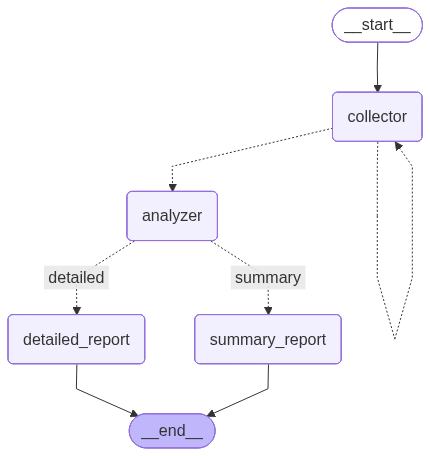

In [12]:
from IPython.display import Image, display

try:
    # 그래프 구조를 Mermaid 형식의 PNG 이미지로 생성하여 표시합니다.
    display(Image(persistent_graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"시각화 중 오류 발생: {e}")
    print("참고: 시각화 라이브러리(pygraphviz 등)가 필요할 수 있습니다.")

### ⚖️ 노드 가중치(우선순위) 적용 및 로직 수정

상태 객체에 가중치 필드를 추가하고, 노드 함수가 이 값을 참조하여 동작을 바꾸도록 수정합니다.

In [13]:
from dataclasses import dataclass, field

# 1. 가중치(priority_weight) 필드가 추가된 새로운 상태 정의
@dataclass
class WeightedState(ComplexState):
    priority_weight: float = 1.0  # 기본 가중치

# 2. 가중치를 반영하도록 노드 함수 수정
def weighted_collector_node(state: WeightedState):
    # 가중치가 높을수록 한 번에 더 많은 데이터를 수집하도록 로직 수정
    collect_count = int(2 * state.priority_weight)
    print(f"--- [Weighted Collector] 가중치({state.priority_weight}) 적용: {collect_count}개 수집 --- ")

    new_data = [f"Data_{random.randint(1, 100)}" for _ in range(collect_count)]
    state.data_points.extend(new_data)
    state.iteration_count += 1
    return state

# 3. 그래프 재구축 및 가중치 테스트
weighted_builder = StateGraph(WeightedState)
weighted_builder.add_node("collector", weighted_collector_node)
weighted_builder.add_node("analyzer", analyzer_node)
weighted_builder.add_node("summary_report", summary_report_node)

weighted_builder.set_entry_point("collector")
weighted_builder.add_edge("collector", "analyzer")
weighted_builder.add_edge("analyzer", "summary_report")
weighted_builder.add_edge("summary_report", END)

weighted_workflow = weighted_builder.compile()

# 가중치를 3.0으로 높게 설정하여 실행해봅니다.
test_state = WeightedState(priority_weight=3.0)
result = weighted_workflow.invoke(test_state)

print(f"\n최종 데이터 개수: {len(result['data_points'])}")

--- [Weighted Collector] 가중치(3.0) 적용: 6개 수집 --- 
--- [Analyzer] 데이터 심층 분석 중 ---
--- [Reporter] 요약 보고서 작성 중 --- 

최종 데이터 개수: 6


### 🧠 제어 변수 추가: 분석 깊이(Analysis Depth) 조절

`analysis_depth` 변수를 통해 에이전트가 생성하는 분석 결과의 상세 수준을 제어합니다.

In [14]:
from dataclasses import dataclass

# 1. 새로운 제어 변수 'analysis_depth' 추가
@dataclass
class AdvancedWeightedState(WeightedState):
    analysis_depth: str = "low"  # "low" 또는 "high"

# 2. 분석 깊이에 따라 동작하는 노드 함수 정의
def advanced_analyzer_node(state: AdvancedWeightedState):
    print(f"--- [Advanced Analyzer] 분석 깊이({state.analysis_depth}) 모드로 실행 중 ---")

    base_result = "상세 분석 결과: 시장 변동성이 매우 높음" if len(state.data_points) > 4 else "일반 분석 결과: 안정적임"

    if state.analysis_depth == "high":
        state.analysis_result = f"{base_result} | [심층 진단] 매크로 지표와 기술적 지표를 결합한 결과, 현재 추세는 강력한 지지선 위에 형성되어 있음."
    else:
        state.analysis_result = f"{base_result} | [간편 진단] 현재 지표 정상."

    return state

# 3. 그래프 재구축
adv_builder = StateGraph(AdvancedWeightedState)
adv_builder.add_node("collector", weighted_collector_node)
adv_builder.add_node("analyzer", advanced_analyzer_node)
adv_builder.add_node("summary_report", summary_report_node)

adv_builder.set_entry_point("collector")
adv_builder.add_edge("collector", "analyzer")
adv_builder.add_edge("analyzer", "summary_report")
adv_builder.add_edge("summary_report", END)

adv_workflow = adv_builder.compile()

# 4. 분석 깊이를 'high'로 설정하여 테스트
print("=== [테스트] 분석 깊이: high ===")
high_depth_state = AdvancedWeightedState(priority_weight=2.0, analysis_depth="high")
result_high = adv_workflow.invoke(high_depth_state)
display(result_high['analysis_result'])

print("\n=== [테스트] 분석 깊이: low ===")
low_depth_state = AdvancedWeightedState(priority_weight=1.0, analysis_depth="low")
result_low = adv_workflow.invoke(low_depth_state)
display(result_low['analysis_result'])


=== [테스트] 분석 깊이: high ===
--- [Weighted Collector] 가중치(2.0) 적용: 4개 수집 --- 
--- [Advanced Analyzer] 분석 깊이(high) 모드로 실행 중 ---
--- [Reporter] 요약 보고서 작성 중 --- 


'일반 분석 결과: 안정적임 | [심층 진단] 매크로 지표와 기술적 지표를 결합한 결과, 현재 추세는 강력한 지지선 위에 형성되어 있음.'


=== [테스트] 분석 깊이: low ===
--- [Weighted Collector] 가중치(1.0) 적용: 2개 수집 --- 
--- [Advanced Analyzer] 분석 깊이(low) 모드로 실행 중 ---
--- [Reporter] 요약 보고서 작성 중 --- 


'일반 분석 결과: 안정적임 | [간편 진단] 현재 지표 정상.'

### 🎭 페르소나 설정: 에이전트 역할(Role Type) 추가

`role_type` 변수를 추가하여 에이전트의 성격에 따라 보고서의 톤앤매너를 다르게 생성합니다.

In [15]:
from dataclasses import dataclass

# 1. 'role_type' 필드가 추가된 최종 상태 정의
@dataclass
class PersonaState(AdvancedWeightedState):
    role_type: str = "conservative"  # "conservative"(보수적) 또는 "aggressive"(공격적)

# 2. 페르소나를 반영한 보고서 노드 수정
def persona_report_node(state: PersonaState):
    print(f"--- [Persona Reporter] 역할({state.role_type})에 맞춰 보고서 작성 중 ---")

    if state.role_type == "conservative":
        prefix = "[보수적 자산관리자] 현재 시장 상황에서 자본 보존을 최우선으로 합니다."
        advice = "현금 비중을 높이고 안전 자산 위주의 포트폴리오를 유지하세요."
    else:
        prefix = "[공격적 투자전략가] 현재의 변동성을 수익 창출의 기회로 포착합니다."
        advice = "저점 매수 전략을 통해 공격적으로 비중을 확대할 시점입니다."

    state.final_output = f"{prefix}\n분석: {state.analysis_result}\n권고: {advice}"
    return state

# 3. 그래프 재구축
persona_builder = StateGraph(PersonaState)
persona_builder.add_node("collector", weighted_collector_node)
persona_builder.add_node("analyzer", advanced_analyzer_node)
persona_builder.add_node("reporter", persona_report_node)

persona_builder.set_entry_point("collector")
persona_builder.add_edge("collector", "analyzer")
persona_builder.add_edge("analyzer", "reporter")
persona_builder.add_edge("reporter", END)

persona_workflow = persona_builder.compile()

# 4. 서로 다른 페르소나 테스트
print("=== [테스트 1] 보수적 관리자 ===")
con_state = PersonaState(role_type="conservative", analysis_depth="low")
result_con = persona_workflow.invoke(con_state)
print(result_con['final_output'])

print("\n=== [테스트 2] 공격적 전략가 ===")
agg_state = PersonaState(role_type="aggressive", analysis_depth="high", priority_weight=2.0)
result_agg = persona_workflow.invoke(agg_state)
print(result_agg['final_output'])


=== [테스트 1] 보수적 관리자 ===
--- [Weighted Collector] 가중치(1.0) 적용: 2개 수집 --- 
--- [Advanced Analyzer] 분석 깊이(low) 모드로 실행 중 ---
--- [Persona Reporter] 역할(conservative)에 맞춰 보고서 작성 중 ---
[보수적 자산관리자] 현재 시장 상황에서 자본 보존을 최우선으로 합니다.
분석: 일반 분석 결과: 안정적임 | [간편 진단] 현재 지표 정상.
권고: 현금 비중을 높이고 안전 자산 위주의 포트폴리오를 유지하세요.

=== [테스트 2] 공격적 전략가 ===
--- [Weighted Collector] 가중치(2.0) 적용: 4개 수집 --- 
--- [Advanced Analyzer] 분석 깊이(high) 모드로 실행 중 ---
--- [Persona Reporter] 역할(aggressive)에 맞춰 보고서 작성 중 ---
[공격적 투자전략가] 현재의 변동성을 수익 창출의 기회로 포착합니다.
분석: 일반 분석 결과: 안정적임 | [심층 진단] 매크로 지표와 기술적 지표를 결합한 결과, 현재 추세는 강력한 지지선 위에 형성되어 있음.
권고: 저점 매수 전략을 통해 공격적으로 비중을 확대할 시점입니다.


### 🚀 통합 제어 에이전트: Final Workflow

모든 제어 변수를 결합하여 상황에 따라 유연하게 동작하는 최종 지능형 에이전트입니다.

In [16]:
import random
from typing import Literal
from dataclasses import dataclass, field
from langgraph.graph import StateGraph, END

# 1. 통합 상태 정의
@dataclass
class IntegratedState:
    # 데이터 관련
    data_points: list = field(default_factory=list)
    analysis_result: str = ""
    final_output: str = ""

    # 제어 변수 (Control Variables)
    priority_weight: float = 1.0     # 데이터 수집량 조절
    analysis_depth: str = "low"      # 분석의 상세도 (low/high)
    role_type: str = "conservative" # 페르소나 (conservative/aggressive)

    # 내부 카운터
    iteration_count: int = 0

# 2. 통합 노드 함수 정의

def unified_collector(state: IntegratedState):
    collect_count = int(2 * state.priority_weight)
    print(f"[Step 1] Collector: 가중치 {state.priority_weight} 적용, {collect_count}개 수집 중...")
    new_data = [f"Info_{random.randint(100, 999)}" for _ in range(collect_count)]
    state.data_points.extend(new_data)
    state.iteration_count += 1
    return state

def unified_analyzer(state: IntegratedState):
    print(f"[Step 2] Analyzer: '{state.analysis_depth}' 모드 분석 실행 중...")
    base = f"데이터 {len(state.data_points)}개 기반 시장 진단 완료."

    if state.analysis_depth == "high":
        state.analysis_result = f"{base} | [심층] 거시 경제 지표와 연계하여 변동성 추세의 기술적 반등 가능성을 확인했습니다."
    else:
        state.analysis_result = f"{base} | [기본] 현재 지표는 안정 범위 내에 있습니다."
    return state

def unified_reporter(state: IntegratedState):
    print(f"[Step 3] Reporter: '{state.role_type}' 페르소나로 최종 보고서 작성 중...")

    if state.role_type == "conservative":
        tone = "[보수적 전략] 위험 회피를 위해 분산 투자와 현금 확보를 제안합니다."
    else:
        tone = "[공격적 전략] 현재의 눌림목을 기회로 적극적인 매수 포지션을 추천합니다."

    state.final_output = f"### 최종 투자 전략 보고서 ###\n{tone}\n\n분석 결과: {state.analysis_result}"
    return state

# 3. 그래프 구축
final_builder = StateGraph(IntegratedState)

final_builder.add_node("collector", unified_collector)
final_builder.add_node("analyzer", unified_analyzer)
final_builder.add_node("reporter", unified_reporter)

final_builder.set_entry_point("collector")
final_builder.add_edge("collector", "analyzer")
final_builder.add_edge("analyzer", "reporter")
final_builder.add_edge("reporter", END)

final_agent = final_builder.compile()

# 4. 테스트 실행 (공격적/심층 분석/높은 가중치 세팅)
print("=== 통합 에이전트 가동 (High Priority & Aggressive) ===")
config_input = IntegratedState(
    priority_weight=2.5,
    analysis_depth="high",
    role_type="aggressive"
)

final_res = final_agent.invoke(config_input)
print("\n" + "="*40)
print(final_res['final_output'])
print("="*40)

=== 통합 에이전트 가동 (High Priority & Aggressive) ===
[Step 1] Collector: 가중치 2.5 적용, 5개 수집 중...
[Step 2] Analyzer: 'high' 모드 분석 실행 중...
[Step 3] Reporter: 'aggressive' 페르소나로 최종 보고서 작성 중...

### 최종 투자 전략 보고서 ###
[공격적 전략] 현재의 눌림목을 기회로 적극적인 매수 포지션을 추천합니다.

분석 결과: 데이터 5개 기반 시장 진단 완료. | [심층] 거시 경제 지표와 연계하여 변동성 추세의 기술적 반등 가능성을 확인했습니다.


### 📦 모듈화: 워크플로우를 파일로 저장하기

이 셀을 실행하면 현재의 통합 에이전트 로직이 `integrated_agent.py`라는 파일로 저장됩니다.

In [19]:
agent_code = """
import random
from typing import Literal
from dataclasses import dataclass, field
from langgraph.graph import StateGraph, END

@dataclass
class IntegratedState:
    data_points: list = field(default_factory=list)
    analysis_result: str = ""
    final_output: str = ""
    priority_weight: float = 1.0
    analysis_depth: str = "low"
    role_type: str = "conservative"
    iteration_count: int = 0

def unified_collector(state: IntegratedState):
    collect_count = int(2 * state.priority_weight)
    new_data = [f"Info_{random.randint(100, 999)}" for _ in range(collect_count)]
    state.data_points.extend(new_data)
    state.iteration_count += 1
    return state

def unified_analyzer(state: IntegratedState):
    base = f"데이터 {len(state.data_points)}개 기반 시장 진단 완료."
    if state.analysis_depth == "high":
        state.analysis_result = f"{base} | [심층] 거시 경제 지표 연계 분석 완료."
    else:
        state.analysis_result = f"{base} | [기본] 지표 정상."
    return state

def unified_reporter(state: IntegratedState):
    if state.role_type == "conservative":
        tone = "[보수적] 위험 회피 전략."
    else:
        tone = "[공격적] 수익 극대화 전략."
    state.final_output = f"{tone}\\n분석: {state.analysis_result}"
    return state

def create_agent():
    builder = StateGraph(IntegratedState)
    builder.add_node("collector", unified_collector)
    builder.add_node("analyzer", unified_analyzer)
    builder.add_node("reporter", unified_reporter)
    builder.set_entry_point("collector")
    builder.add_edge("collector", "analyzer")
    builder.add_edge("analyzer", "reporter")
    builder.add_edge("reporter", END)
    return builder.compile()
"""

with open("integrated_agent.py", "w", encoding="utf-8") as f:
    f.write(agent_code.strip())

print("integrated_agent.py 파일 수정 및 저장 완료!")

integrated_agent.py 파일 수정 및 저장 완료!


### 🧩 모듈 불러오기 및 사용 테스트

방금 저장한 파일을 `import`하여 에이전트를 생성하고 실행해봅니다.

In [20]:
import integrated_agent
import importlib

# 수정된 파일을 반영하기 위해 리로드합니다.
importlib.reload(integrated_agent)

try:
    # 모듈 내의 함수와 클래스를 사용하여 에이전트 생성
    my_agent = integrated_agent.create_agent()
    test_input = integrated_agent.IntegratedState(
        priority_weight=1.5,
        analysis_depth="low",
        role_type="conservative"
    )

    output = my_agent.invoke(test_input)
    print("--- 모듈 실행 결과 ---")
    print(output['final_output'])
except Exception as e:
    print(f"에러 발생: {e}")

--- 모듈 실행 결과 ---
[보수적] 위험 회피 전략.
분석: 데이터 3개 기반 시장 진단 완료. | [기본] 지표 정상.


### 📊 외부 데이터(CSV) 로드 및 에이전트 연동

이전에 생성한 `nvda_financial_data.csv` 파일을 읽어와서 에이전트의 입력 상태를 구성합니다.

In [22]:
import pandas as pd
import yfinance as yf
import integrated_agent
import importlib
import os

# 최신 모듈 상태 유지
importlib.reload(integrated_agent)

try:
    # 1. 파일이 없으면 현재 경로에 새로 생성 (방어적 코드)
    file_name = "nvda_financial_data.csv"
    if not os.path.exists(file_name):
        print(f"{file_name}이 없어 새로 다운로드합니다...")
        df_new = yf.download("NVDA", start="2025-01-01", end="2026-06-01")
        df_new.to_csv(file_name)

    # 2. 외부 데이터 로드
    df_nvda = pd.read_csv(file_name)
    row_count = len(df_nvda)
    print(f"성공: {row_count}개의 행을 가진 데이터를 로드했습니다.")

    # 3. 데이터 기반 제어 변수 결정 로직
    # 데이터 양에 따라 분석의 깊이와 수집 가중치를 동적으로 조절
    depth = "high" if row_count > 50 else "low"
    weight = 1.0 + (row_count / 100) # 데이터가 많을수록 더 많은 추가 정보를 원함

    # 4. 에이전트 입력 상태 구성
    external_input = integrated_agent.IntegratedState(
        data_points=[f"Loaded_CSV_Rows_{row_count}"],
        priority_weight=round(weight, 1),
        analysis_depth=depth,
        role_type="aggressive"
    )

    # 5. 에이전트 실행
    agent = integrated_agent.create_agent()
    final_result = agent.invoke(external_input)

    print(f"\n[설정값] Depth: {depth}, Weight: {round(weight, 1)}")
    print("--- 외부 데이터 연동 실행 결과 ---")
    print(final_result['final_output'])

except Exception as e:
    print(f"오류 발생: {e}")

nvda_financial_data.csv이 없어 새로 다운로드합니다...


/tmp/ipykernel_461/3945724724.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_new = yf.download("NVDA", start="2025-01-01", end="2026-06-01")
[*********************100%***********************]  1 of 1 completed

성공: 354개의 행을 가진 데이터를 로드했습니다.

[설정값] Depth: high, Weight: 4.5
--- 외부 데이터 연동 실행 결과 ---
[공격적] 수익 극대화 전략.
분석: 데이터 10개 기반 시장 진단 완료. | [심층] 거시 경제 지표 연계 분석 완료.


### 📈 범용 주식 분석 파이프라인 구축

티커(Ticker)만 입력하면 데이터 수집부터 에이전트 리포트 생성까지 자동으로 수행하는 통합 함수를 정의합니다.

In [23]:
import pandas as pd
import yfinance as yf
import integrated_agent
import importlib
import os

def run_stock_analysis_pipeline(ticker: str, role: str = "aggressive"):
    print(f"\n[System] {ticker} 주식 분석 파이프라인 가동 시작...")
    importlib.reload(integrated_agent)

    # 1. 데이터 다운로드
    file_path = f"{ticker.lower()}_data.csv"
    df = yf.download(ticker, start="2025-01-01", end="2026-06-01", progress=False)
    df.to_csv(file_path)

    row_count = len(df)
    print(f"[Data] {ticker} 데이터 {row_count}행 로드 완료.")

    # 2. 동적 파라미터 설정
    depth = "high" if row_count > 100 else "low"
    weight = round(1.0 + (row_count / 150), 1)

    # 3. 에이전트 상태 구성
    state = integrated_agent.IntegratedState(
        data_points=[f"{ticker} Analysis Start"],
        priority_weight=weight,
        analysis_depth=depth,
        role_type=role
    )

    # 4. 에이전트 실행
    agent = integrated_agent.create_agent()
    result = agent.invoke(state)

    print(f"[Config] Role: {role}, Depth: {depth}, Weight: {weight}")
    print("="*50)
    print(f"<{ticker} 분석 보고서>")
    print(result['final_output'])
    print("="*50)

# 테스트: 테슬라(TSLA)와 애플(AAPL) 분석
run_stock_analysis_pipeline("TSLA", role="aggressive")
run_stock_analysis_pipeline("AAPL", role="conservative")


[System] TSLA 주식 분석 파이프라인 가동 시작...


/tmp/ipykernel_461/3159205482.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2025-01-01", end="2026-06-01", progress=False)


[Data] TSLA 데이터 352행 로드 완료.
[Config] Role: aggressive, Depth: high, Weight: 3.3
<TSLA 분석 보고서>
[공격적] 수익 극대화 전략.
분석: 데이터 7개 기반 시장 진단 완료. | [심층] 거시 경제 지표 연계 분석 완료.

[System] AAPL 주식 분석 파이프라인 가동 시작...


/tmp/ipykernel_461/3159205482.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2025-01-01", end="2026-06-01", progress=False)


[Data] AAPL 데이터 352행 로드 완료.
[Config] Role: conservative, Depth: high, Weight: 3.3
<AAPL 분석 보고서>
[보수적] 위험 회피 전략.
분석: 데이터 7개 기반 시장 진단 완료. | [심층] 거시 경제 지표 연계 분석 완료.


### 🤖 LLM API 연동: 실제 추론 노드로 업그레이드

기본 시뮬레이션 로직을 제거하고, `langchain_openai`를 사용하여 실제 LLM이 시장 데이터를 분석하도록 `integrated_agent.py`를 업데이트합니다.

In [26]:
import os

# 1. LLM 연동 버전의 에이전트 코드 작성 (f-string 문법 오류 수정 버전)
upgraded_agent_code = """
import os
import random
from typing import Literal
from dataclasses import dataclass, field
from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage

@dataclass
class IntegratedState:
    data_points: list = field(default_factory=list)
    analysis_result: str = ""
    final_output: str = ""
    priority_weight: float = 1.0
    analysis_depth: str = "low"
    role_type: str = "conservative"
    iteration_count: int = 0

def unified_collector(state: IntegratedState):
    collect_count = int(2 * state.priority_weight)
    new_data = [f"Technical_Indicator_{random.randint(100, 999)}" for _ in range(collect_count)]
    state.data_points.extend(new_data)
    state.iteration_count += 1
    return state

def unified_analyzer(state: IntegratedState):
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.3)

    # f-string 내 줄바꿈 오류를 방지하기 위해 단일 행으로 구성하거나 명시적 개행 사용
    prompt = f"당신은 금융 분석가입니다. 수집된 데이터 포인트: {state.data_points}. 분석 깊이: {state.analysis_depth}. 위 정보를 바탕으로 현재 시장 상황에 대한 핵심 요약을 한 문장으로 작성하세요."

    response = llm.invoke([SystemMessage(content="금융 시장 전문가로서 답변하세요."), HumanMessage(content=prompt)])
    state.analysis_result = response.content
    return state

def unified_reporter(state: IntegratedState):
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.7)

    role_prompt = "보수적 자산 관리자 (위험 회피)" if state.role_type == "conservative" else "공격적 투자 전략가 (수익 극대화)"

    prompt = f"당신의 페르소나: {role_prompt}. 분석 결과: {state.analysis_result}. 위 분석을 바탕으로 투자자에게 줄 최종 권고안을 {state.role_type} 관점에서 작성하세요."

    response = llm.invoke([SystemMessage(content=f"당신은 {role_prompt}입니다."), HumanMessage(content=prompt)])
    state.final_output = f"### AI 지능형 리포트 ({state.role_type}) ###\\n{response.content}"
    return state

def create_agent():
    builder = StateGraph(IntegratedState)
    builder.add_node("collector", unified_collector)
    builder.add_node("analyzer", unified_analyzer)
    builder.add_node("reporter", unified_reporter)
    builder.set_entry_point("collector")
    builder.add_edge("collector", "analyzer")
    builder.add_edge("analyzer", "reporter")
    builder.add_edge("reporter", END)
    return builder.compile()
"""

# 2. 파일 덮어쓰기
with open("integrated_agent.py", "w", encoding="utf-8") as f:
    f.write(upgraded_agent_code.strip())

print("integrated_agent.py 가 LLM 연동 버전으로 업그레이드되었습니다!")

integrated_agent.py 가 LLM 연동 버전으로 업그레이드되었습니다!


In [25]:
# 3. 실제 LLM 기반 파이프라인 재실행 테스트
importlib.reload(integrated_agent)

print("--- 실제 LLM 호출을 포함한 TSLA 분석 시작 ---")
run_stock_analysis_pipeline("TSLA", role="aggressive")

--- 실제 LLM 호출을 포함한 TSLA 분석 시작 ---

[System] TSLA 주식 분석 파이프라인 가동 시작...
[Data] TSLA 데이터 352행 로드 완료.
[Config] Role: aggressive, Depth: high, Weight: 3.3
<TSLA 분석 보고서>
[공격적] 수익 극대화 전략.
분석: 데이터 7개 기반 시장 진단 완료. | [심층] 거시 경제 지표 연계 분석 완료.


/tmp/ipykernel_461/3159205482.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2025-01-01", end="2026-06-01", progress=False)
